In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib


In [2]:
df = pd.read_csv('chrun anaylsis dataset.csv')

In [3]:
df.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,19877-DEL,Male,35,No,Delhi,7,27,NaN,Yes,No,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,58353-MAH,Female,45,Yes,Maharashtra,14,13,NaN,Yes,Yes,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,25063-WES,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,59787-KAR,Male,79,No,Karnataka,3,21,Deal 4,Yes,No,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,28544-TAM,Female,80,No,Tamil Nadu,3,8,NaN,Yes,No,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6418 entries, 0 to 6417
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6418 non-null   object 
 1   Gender                       6418 non-null   object 
 2   Age                          6418 non-null   int64  
 3   Married                      6418 non-null   object 
 4   State                        6418 non-null   object 
 5   Number_of_Referrals          6418 non-null   int64  
 6   Tenure_in_Months             6418 non-null   int64  
 7   Value_Deal                   2870 non-null   object 
 8   Phone_Service                6418 non-null   object 
 9   Multiple_Lines               5796 non-null   object 
 10  Internet_Service             6418 non-null   object 
 11  Internet_Type                5028 non-null   object 
 12  Online_Security              5028 non-null   object 
 13  Online_Backup     

In [5]:
df.isnull().sum()

Customer_ID                       0
Gender                            0
Age                               0
Married                           0
State                             0
Number_of_Referrals               0
Tenure_in_Months                  0
Value_Deal                     3548
Phone_Service                     0
Multiple_Lines                  622
Internet_Service                  0
Internet_Type                  1390
Online_Security                1390
Online_Backup                  1390
Device_Protection_Plan         1390
Premium_Support                1390
Streaming_TV                   1390
Streaming_Movies               1390
Streaming_Music                1390
Unlimited_Data                 1390
Contract                          0
Paperless_Billing                 0
Payment_Method                    0
Monthly_Charge                    0
Total_Charges                     0
Total_Refunds                     0
Total_Extra_Data_Charges          0
Total_Long_Distance_Charges 

In [6]:
df.describe()

,Age,Number_of_Referrals,Tenure_in_Months,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue
count,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000
mean,47.070739,7.427859,17.342786,63.652867,2280.374858,1.924944,6.718604,748.703468,3033.871987
std,16.703633,4.621519,10.576391,31.188823,2268.049985,7.849083,24.722533,847.672844,2866.505426
min,18.000000,0.000000,1.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,33.000000,3.000000,8.000000,30.562500,395.725000,0.000000,0.000000,70.805000,603.742500
50%,46.000000,7.000000,16.000000,70.100000,1396.125000,0.000000,0.000000,407.475000,2108.635000
75%,60.000000,11.000000,27.000000,89.750000,3783.600000,0.000000,0.000000,1182.917500,4801.537500
max,85.000000,15.000000,36.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


In [7]:
df.tail()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
6413,43397-UTT,Female,41,No,Uttar Pradesh,6,33,NaN,Yes,Yes,...,Credit Card,74.40,896.75,0.0,0,37.96,934.71,Churned,Competitor,Competitor made better offer
6414,22240-HAR,Male,51,Yes,Haryana,0,19,Deal 1,No,NaN,...,Credit Card,45.25,3139.80,0.0,0,0.00,3139.80,Stayed,NaN,NaN
6415,78682-KER,Female,65,Yes,Kerala,14,25,NaN,Yes,Yes,...,Bank Withdrawal,74.95,2869.85,0.0,0,599.64,3469.49,Churned,Dissatisfaction,Product dissatisfaction
6416,17816-ODI,Male,23,No,Odisha,2,10,NaN,Yes,Yes,...,Credit Card,70.15,4480.70,0.0,0,2107.52,6588.22,Stayed,NaN,NaN
6417,34476-TAM,Male,73,No,Tamil Nadu,13,21,NaN,Yes,No,...,Bank Withdrawal,96.85,1235.55,0.0,0,346.84,1582.39,Stayed,NaN,NaN


## number of rows and columns

In [8]:
print(" the metadata of the dataset : ", df.shape)

 the metadata of the dataset :  (6418, 32)


In [9]:
df.columns

Index(['Customer_ID', 'Gender', 'Age', 'Married', 'State',
       'Number_of_Referrals', 'Tenure_in_Months', 'Value_Deal',
       'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Internet_Type',
       'Online_Security', 'Online_Backup', 'Device_Protection_Plan',
       'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
       'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Monthly_Charge', 'Total_Charges', 'Total_Refunds',
       'Total_Extra_Data_Charges', 'Total_Long_Distance_Charges',
       'Total_Revenue', 'Customer_Status', 'Churn_Category', 'Churn_Reason'],
      dtype='object')

In [10]:
df.dtypes

Customer_ID                     object
Gender                          object
Age                              int64
Married                         object
State                           object
Number_of_Referrals              int64
Tenure_in_Months                 int64
Value_Deal                      object
Phone_Service                   object
Multiple_Lines                  object
Internet_Service                object
Internet_Type                   object
Online_Security                 object
Online_Backup                   object
Device_Protection_Plan          object
Premium_Support                 object
Streaming_TV                    object
Streaming_Movies                object
Streaming_Music                 object
Unlimited_Data                  object
Contract                        object
Paperless_Billing               object
Payment_Method                  object
Monthly_Charge                 float64
Total_Charges                  float64
Total_Refunds            

Data Preprocessing
# Drop columns that won't be used for prediction


In [11]:
df = df.drop(['Customer_ID', 'Churn_Category', 'Churn_Reason'], axis=1)

In [12]:
df.columns 

Index(['Gender', 'Age', 'Married', 'State', 'Number_of_Referrals',
       'Tenure_in_Months', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',
       'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',
       'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV',
       'Streaming_Movies', 'Streaming_Music', 'Unlimited_Data', 'Contract',
       'Paperless_Billing', 'Payment_Method', 'Monthly_Charge',
       'Total_Charges', 'Total_Refunds', 'Total_Extra_Data_Charges',
       'Total_Long_Distance_Charges', 'Total_Revenue', 'Customer_Status'],
      dtype='object')

In [13]:
print(" the metadata of the dataset : ", df.shape)

 the metadata of the dataset :  (6418, 29)


### Core kPI'S

In [14]:
total_customers = df.shape[0]
total_churn = df[df['Customer_Status']
== 'Churned'].shape[0]
churn_rate = round((total_churn / total_customers) * 100, 2)

new_joiners = df[df['Customer_Status']=='joined'].shape[0]
retention_rate = round(100 - churn_rate, 2)

print(total_customers)
print(total_churn)
print(churn_rate)
print(new_joiners)
print(retention_rate)

6418
1732
26.99
0
73.01


## KPI Table

In [15]:
kpi_df = pd.DataFrame({
    'kPI': ['Total Customers','Total Churn','Churn Rate %','New Joiners','retention Rate %'],
    'Value':[total_customers,total_churn,churn_rate,new_joiners,retention_rate]})

kpi_df

,kPI,Value
0,Total Customers,6418.00
1,Total Churn,1732.00
2,Churn Rate %,26.99
3,(New Joiners,0.00
4,retention Rate %,73.01


## Charts

## Churn Rate By Gender

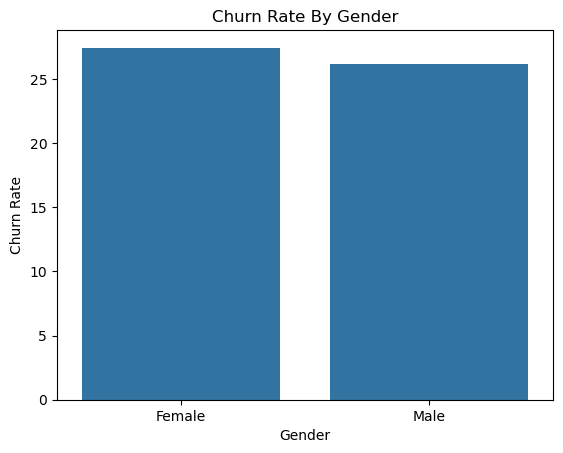

In [16]:
gender_churn = (
    df.assign(Churn_Flag = 
    df['Customer_Status'].eq('Churned'))
        .groupby('Gender')['Churn_Flag']
        .mean()
        .mul(100)
        .reset_index(name='Churn Rate')
)    

sns.barplot(data=gender_churn,x='Gender',y='Churn Rate')
plt.title('Churn Rate By Gender')
plt.show()

## Churn Rate By Contract


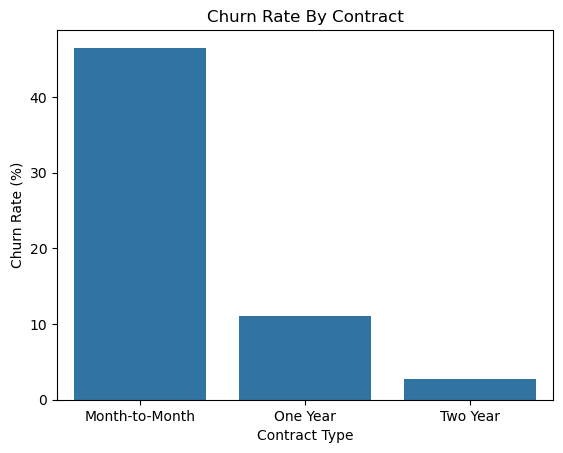

In [17]:
contract_churn = (
    df.assign(Churn_Flag = 
    df['Customer_Status'].eq('Churned'))
        .groupby('Contract')['Churn_Flag']
        .mean()
        .mul(100)
        .reset_index(name='Churn Rate')
)    

sns.barplot(data=contract_churn,x='Contract',y='Churn Rate')
plt.title('Churn Rate By Contract')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.show()

## Churn Rate By Payment Method

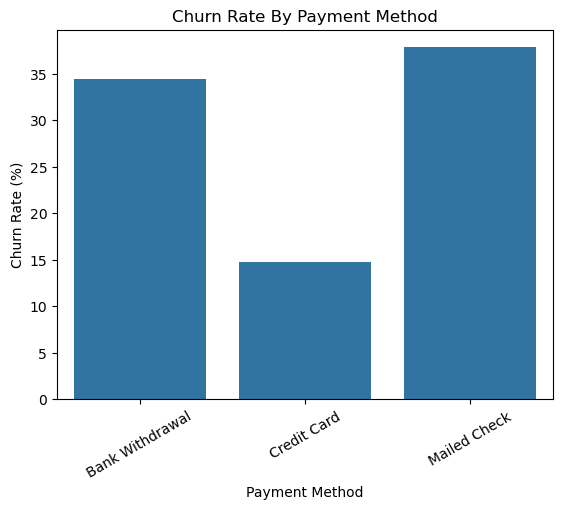

In [18]:
payment_churn = (
    df.assign(Churn_Flag = 
    df['Customer_Status'].eq('Churned'))
        .groupby('Payment_Method')['Churn_Flag']
        .mean()
        .mul(100)
        .reset_index(name='Churn Rate')
)    

sns.barplot(data=payment_churn,x='Payment_Method',y='Churn Rate')
plt.title('Churn Rate By Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=30)
plt.show()  

## Churn Rate By Internet Type

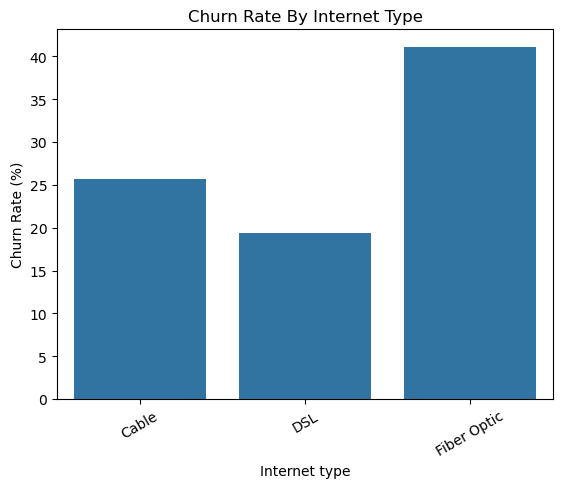

In [19]:
 internet_churn = (
    df.assign(Churn_Flag = 
    df['Customer_Status'].eq('Churned'))
        .groupby('Internet_Type')['Churn_Flag']
        .mean()
        .mul(100)
        .reset_index(name='Churn Rate')
)    

sns.barplot(data=internet_churn,x='Internet_Type',y='Churn Rate')
plt.title('Churn Rate By Internet Type')
plt.xlabel('Internet type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=30)
plt.show()  

## Churn By Tenure Group

C:\Users\User\AppData\Local\Temp\ipykernel_6752\1765901132.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Tenure_Group')


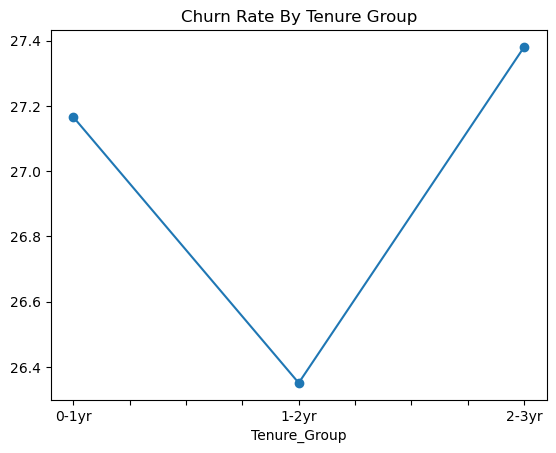

In [20]:
df['Tenure_Group'] = pd.cut(
    df['Tenure_in_Months'],
    bins=[0,12,24,36,48,60,100],

labels=['0-1yr','1-2yr','2-3yr','3-4yr','4-5yr','5+yr']
)

tenure_churn = (
df.groupby('Tenure_Group')
['Customer_Status'].apply(
    lambda x:
    (x=='Churned').mean()*100
)
)
tenure_churn.plot(kind='line',
marker='o',title='Churn Rate By Tenure Group')
plt.show()

## Churn By Age Group

C:\Users\User\AppData\Local\Temp\ipykernel_6752\1444813808.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')


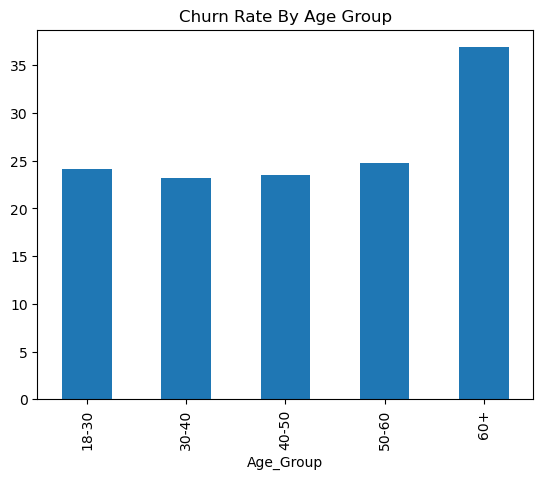

In [21]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[18,30,40,50,60,100],

labels=['18-30','30-40','40-50','50-60','60+']
)

age_churn = (
df.groupby('Age_Group')
['Customer_Status'].apply(
    lambda x:
    (x=='Churned').mean()*100
)
)
age_churn.plot(kind='bar',
title='Churn Rate By Age Group')
plt.show()

## Total Churn By State

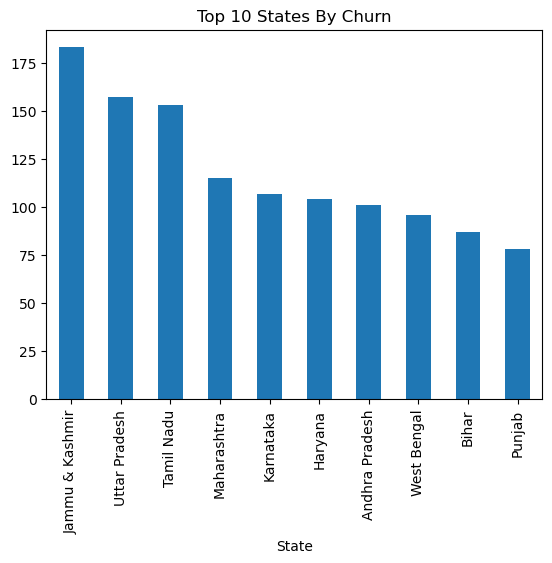

In [22]:
state_churn = (
df[df['Customer_Status']=='Churned'].groupby('State').size().sort_values(ascending=False)
)
state_churn.head(10).plot(kind='bar',title='Top 10 States By Churn')
plt.show()

### Avg Monthly Charges : Chuened V/s Retained

  Customer_Status  Monthly_Charge
0         Churned       73.102252
1          Joined       42.683455
2          Stayed       61.840491


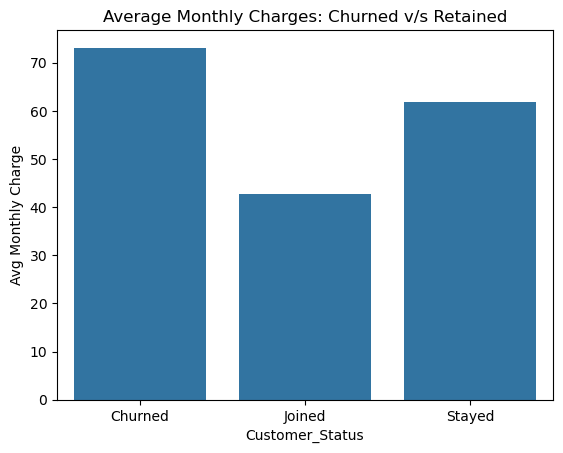

In [23]:
df['Monthly_Charge'] = (
pd.to_numeric(df['Monthly_Charge'],
errors='coerce')
)

avg_monthly_charge = (
    df.groupby('Customer_Status')
    ['Monthly_Charge']
           .mean()
           .reset_index()
)
print(avg_monthly_charge)

sns.barplot(data=avg_monthly_charge,x='Customer_Status',y='Monthly_Charge')

plt.title('Average Monthly Charges: Churned v/s Retained')
plt.ylabel('Avg Monthly Charge')
plt.show()

## Customer LifeTime Value (Approx)

In [24]:
df['LTV'] = df['Monthly_Charge'] * df['Tenure_in_Months']

df.groupby('Customer_Status')['LTV'].mean()

Customer_Status
Churned    1277.044400
Joined      694.830900
Stayed     1070.579146
Name: LTV, dtype: float64

## Correlation Heatmap

<function matplotlib.pyplot.show(close=None, block=None)>

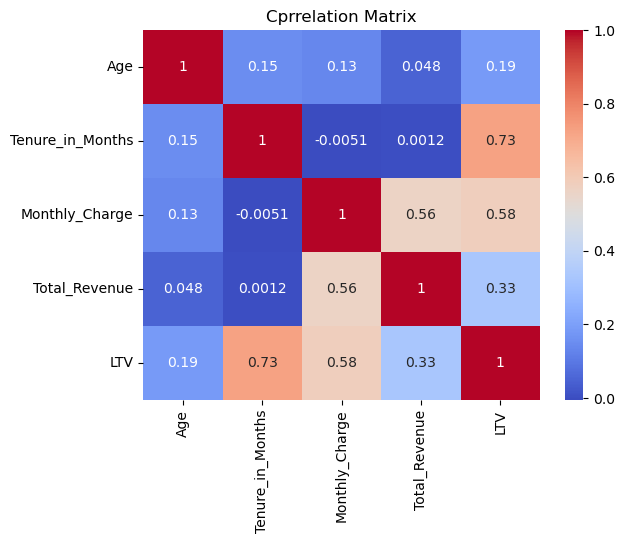

In [25]:
numeric_cols = (
['Age','Tenure_in_Months','Monthly_Charge','Total_Revenue','LTV']
)    

sns.heatmap(df[numeric_cols].corr(),annot=True, cmap='coolwarm')
plt.title('Cprrelation Matrix')
plt.show

## CHURN PREDICTION MODEL

## Target Variable

In [26]:
df['Churn_Flag'] = ( 
df['Customer_Status'].map({'Stayed':0,'Churned':1,'Joined':0})
)

df[['Customer_Status','Churn_Flag']].head()

,Customer_Status,Churn_Flag
0,Stayed,0
1,Stayed,0
2,Churned,1
3,Churned,1
4,Churned,1


## Feature Selection

In [28]:
features = [

 'Age','Tenure_in_Months','Monthly_Charge','Total_Revenue','Contract','Payment_Method','Internet_Type'
]

model_df = df[features + ['Churn_Flag']]
print(model_df)

      Age  Tenure_in_Months  Monthly_Charge  Total_Revenue        Contract  \
0      35                27           65.60         974.81        One Year   
1      45                13           -4.00         610.28  Month-to-Month   
2      51                35           73.90         415.45  Month-to-Month   
3      79                21           98.00        1599.51  Month-to-Month   
4      80                 8           83.90         289.54  Month-to-Month   
...   ...               ...             ...            ...             ...   
6413   41                33           74.40         934.71  Month-to-Month   
6414   51                19           45.25        3139.80        Two Year   
6415   65                25           74.95        3469.49  Month-to-Month   
6416   23                10           70.15        6588.22        One Year   
6417   73                21           96.85        1582.39        Two Year   

       Payment_Method Internet_Type  Churn_Flag  
0         Cre

## Encoding

In [65]:
df_raw = df.copy()

categorical_cols = ['Contract', 'Payment_Method', 'Internet_Type']

model_df = pd.get_dummies(
    df_raw,
    columns=categorical_cols,
    drop_first=True
)

model_df.columns



Index(['Gender', 'Age', 'Married', 'State', 'Number_of_Referrals',
       'Tenure_in_Months', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',
       'Internet_Service', 'Online_Security', 'Online_Backup',
       'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV',
       'Streaming_Movies', 'Streaming_Music', 'Unlimited_Data',
       'Paperless_Billing', 'Monthly_Charge', 'Total_Charges', 'Total_Refunds',
       'Total_Extra_Data_Charges', 'Total_Long_Distance_Charges',
       'Total_Revenue', 'Customer_Status', 'Tenure_Group', 'Age_Group', 'LTV',
       'Churn_Flag', 'Tenure_Month_Bucket', 'Contract_One Year',
       'Contract_Two Year', 'Payment_Method_Credit Card',
       'Payment_Method_Mailed Check', 'Internet_Type_DSL',
       'Internet_Type_Fiber Optic'],
      dtype='object')

## Train-Test Split

In [66]:
x = model_df.drop('Churn_Flag',axis=1)
y= model_df['Churn_Flag']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

## Logistic Regression

In [71]:
x.dtypes[x.dtypes == 'object']

Gender                    object
Married                   object
State                     object
Value_Deal                object
Phone_Service             object
Multiple_Lines            object
Internet_Service          object
Online_Security           object
Online_Backup             object
Device_Protection_Plan    object
Premium_Support           object
Streaming_TV              object
Streaming_Movies          object
Streaming_Music           object
Unlimited_Data            object
Paperless_Billing         object
Customer_Status           object
dtype: object

In [73]:
cat_cols = x.select_dtypes(include='object').columns

x_encoded = pd.get_dummies(
    x,
    columns=cat_cols,
    drop_first=True
)

x_train, x_test, y_train, y_test = train_test_split(
    x_encoded,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)
Female = 0
Male = 1

x_encoded.dtypes.unique()

array([dtype('int64'), dtype('float64'),
       CategoricalDtype(categories=['0-1yr', '1-2yr', '2-3yr', '3-4yr', '4-5yr', '5+yr'], ordered=True, categories_dtype=object),
       CategoricalDtype(categories=['18-30', '30-40', '40-50', '50-60', '60+'], ordered=True, categories_dtype=object),
       CategoricalDtype(categories=[  [0, 5),  [5, 10), [10, 15), [15, 20), [20, 25), [25, 30),
                         [30, 35), [35, 40), [40, 45), [45, 50), [50, 55), [55, 60),
                         [60, 65), [65, 70), [70, 75), [75, 80)],
       , ordered=True, categories_dtype=interval[int64, left])                                 ,
       dtype('bool')], dtype=object)

## Create customer Tenure Buckets(Timeline)

In [1]:
df['Tenure_Month_Bucket'] = pd.cut(
    df['Tenure_in_Months'],
    bins=range(0, 85, 5),
    right=False
)

NameError: name 'pd' is not defined

## churn Trend Over Customer Lifetime

C:\Users\User\AppData\Local\Temp\ipykernel_6752\1789402135.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_trend = df.groupby('Tenure_Month_Bucket')['Customer_Status'] \


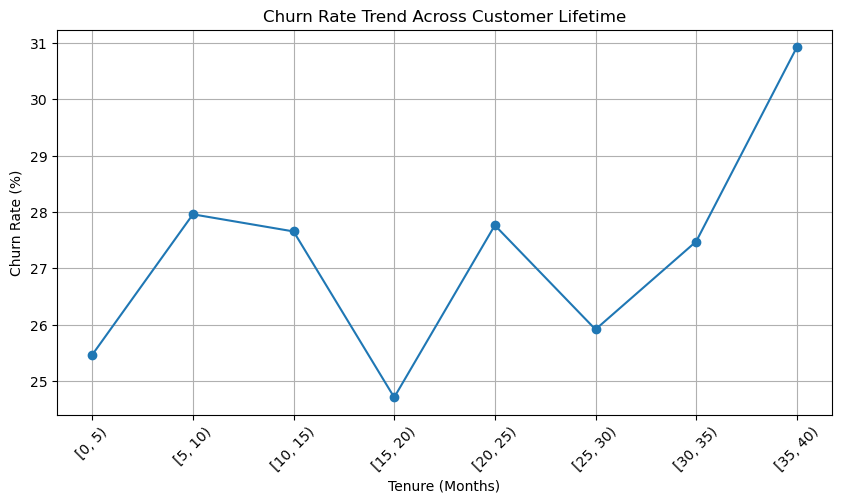

In [45]:
tenure_trend = df.groupby('Tenure_Month_Bucket')['Customer_Status'] \
    .apply(lambda x: (x == 'Churned').mean() * 100) \
    .reset_index(name='Churn_Rate')

plt.figure(figsize=(10,5))
plt.plot(tenure_trend['Tenure_Month_Bucket'].astype(str),
         tenure_trend['Churn_Rate'],
         marker='o')

plt.xticks(rotation=45)
plt.title("Churn Rate Trend Across Customer Lifetime")
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate (%)")
plt.grid(True)
plt.show()

## Revenue Trend By Tenure

C:\Users\User\AppData\Local\Temp\ipykernel_6752\302548531.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_trend = df.groupby('Tenure_Month_Bucket')['Total_Revenue'].sum().reset_index()


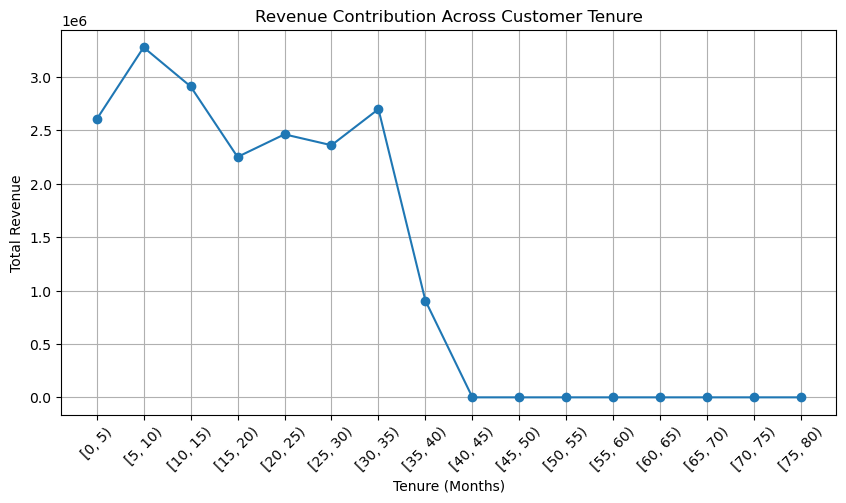

In [46]:
revenue_trend = df.groupby('Tenure_Month_Bucket')['Total_Revenue'].sum().reset_index()

plt.figure(figsize=(10,5))
plt.plot(revenue_trend['Tenure_Month_Bucket'].astype(str),
         revenue_trend['Total_Revenue'],
         marker='o')

plt.xticks(rotation=45)
plt.title("Revenue Contribution Across Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Total Revenue")
plt.grid(True)
plt.show()

## COSTING & REVENUE IMPACT ANALYSIS 

 ## Revenue Lost Due To Churn

In [47]:
churned_customers = df[df['Customer_Status'] == 'Churned']

revenue_lost = churned_customers['Total_Revenue'].sum()
revenue_lost


np.float64(3411960.58)

## Monthly Revenue At Risk

In [48]:
monthly_revenue_lost = churned_customers['Monthly_Charge'].sum()
monthly_revenue_lost


np.float64(126613.09999999999)

## Arerege Revenue Lost Per Churned Customer

In [49]:
avg_revenue_lost_per_customer = churned_customers['Total_Revenue'].mean()
avg_revenue_lost_per_customer

np.float64(1969.9541454965358)

## High-Risk Revenue Segment Analysis

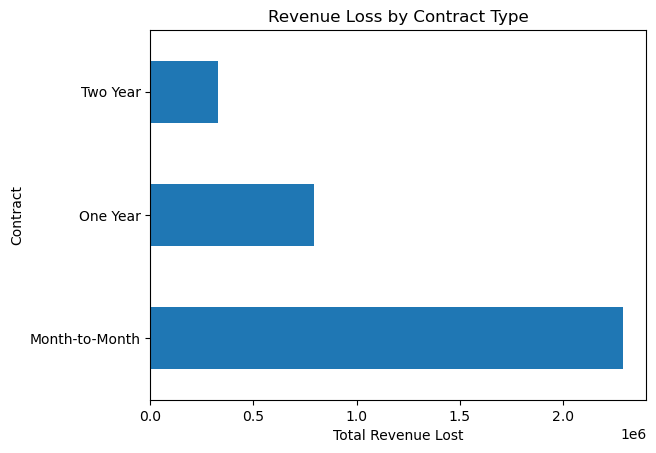

In [50]:
contract_revenue_loss = churned_customers.groupby('Contract')['Total_Revenue'].sum() \
    .sort_values(ascending=False)

contract_revenue_loss.plot(kind='barh', title="Revenue Loss by Contract Type")
plt.xlabel("Total Revenue Lost")
plt.show()


## Cost Of Retention vs Cost Of Churn 


In [51]:
retention_cost = total_churn * 500
acquisition_cost = total_churn * 3000

retention_cost, acquisition_cost


(866000, 5196000)

## Cost Savings Opportunity

In [52]:
cost_savings = acquisition_cost - retention_cost
cost_savings


4330000

## EXECUTIVE KPI SNAPSHOT

In [53]:
executive_summary = pd.DataFrame({
    'Metric': [
        'Total Customers',
        'Total Churned Customers',
        'Churn Rate (%)',
        'Revenue Lost Due to Churn',
        'Monthly Revenue at Risk',
        'Retention Cost',
        'Re-acquisition Cost',
        'Potential Cost Savings'
    ],
    'Value': [
        total_customers,
        total_churn,
        churn_rate,
        revenue_lost,
        monthly_revenue_lost,
        retention_cost,
        acquisition_cost,
        cost_savings
    ]
})

executive_summary

,Metric,Value
0,Total Customers,6418.00
1,Total Churned Customers,1732.00
2,Churn Rate (%),26.99
3,Revenue Lost Due to Churn,3411960.58
4,Monthly Revenue at Risk,126613.10
5,Retention Cost,866000.00
6,Re-acquisition Cost,5196000.00
7,Potential Cost Savings,4330000.00
